In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

C:\Users\seifert\AppData\Local\Temp\ipykernel_27808\75782077.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [29]:
file = r"D:\Dateien\KI_Speicher\LiuDimer\ResultsTestRectWH\res.csv"
file = r"C:\Users\seifert\Pictures\Temp\Out\TestShape4\res.csv"
df = pd.read_csv(file, delimiter=';')

In [30]:
df.keys()

Index(['Unnamed: 0', 'total_id', 'img_id', 'crop_id', 'img_fn', 'crop_fn',
       'p1', 'p2', 'cat', 'conf', 'w_px', 'h_px', 'grid_dist_x_nm',
       'grid_dist_y_nm', 'grid_period_x_nm', 'grid_period_y_nm',
       'on_grid_percentage', 'on_grid', 'mid_x_nm', 'mid_y_nm',
       'centroid_x_nm', 'centroid_y_nm', 'NN1_nm', 'NN2_nm', 'NN3_nm',
       'NN4_nm', 'NN5_nm', 'area', 'area_nm', 'span_x_nm', 'span_y_nm',
       'span_long_axis_nm', 'span_short_axis_nm', 'long_axis_angle',
       'rect_angle', 'rect_width_nm', 'rect_height_nm', 'rect_ioum'],
      dtype='object')

In [31]:
confidences = df['conf']

(0.0, 1.0)

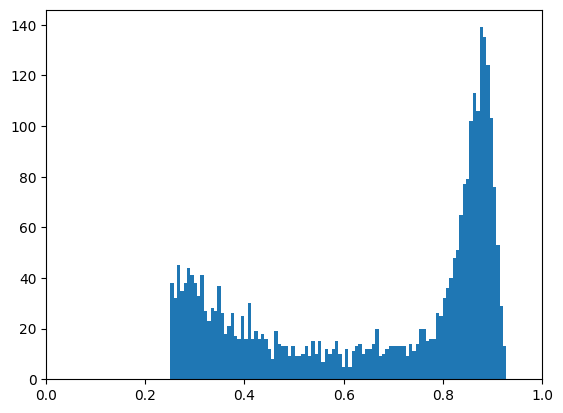

In [32]:
plt.hist(confidences, bins=100)
plt.xlim(0,1)

In [34]:
ious = df['rect_ioum'] if 'rect_ioum' in df.keys() else df['rect_iou']

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,
          0.,   1.,   0.,   2.,   0.,   1.,   2.,   3.,   1.,   0.,   1.,
          0.,   2.,   2.,   2.,   2.,   2.,   1.,   6.,   4.,  10.,  10.,
          9.,  10.,  17.,  12.,  19.,  12.,  19.,  26.,  26.,  48.,  35.,
         36.,  55.,  59.,  49.,  58.,  66.,  63.,  75.,  66.,  86.,  70.,
         83., 105.,  82., 105.,  84.,  94.,  99., 102.,  86., 110., 102.,
         89.,  87.,  82.,  72.,  79.,  61.,  67.,  57.,  55.,  42.,  38.,
         28.,  30.,  24.,  14.,  11.,  10.,  10.,   6.,   4.,   5.,   1.,
          1.]),
 array([0.60378569, 0.60774783, 0.61170998, 0.61567212, 0.61963426,
        0.62359641, 0.62755855, 0.63152069, 0.63548284, 0.63944498,
        0.64340712, 0.64736927, 0.65133141, 0.65529355, 0.65925569,
        0.66321784, 0.66717998, 0.67114212, 0.67510427, 0.67906641,
        0.68302855, 0.6869907 , 0.69095284, 0.

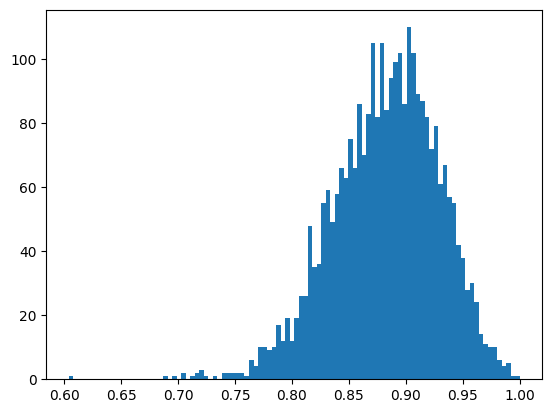

In [35]:
plt.hist(ious, bins=100)

In [36]:
on_grid_percentage = df['on_grid_percentage']

(0.0, 1.0)

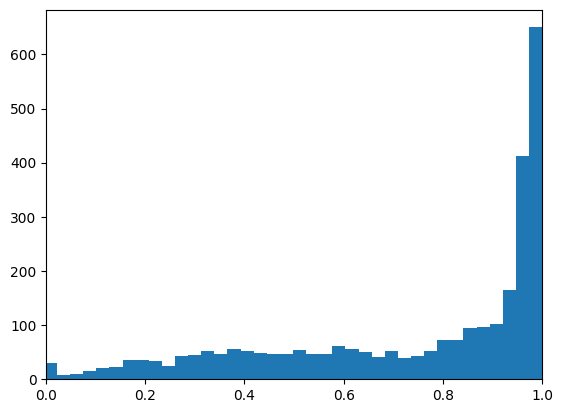

In [37]:
plt.hist(on_grid_percentage, bins=100)
plt.xlim(0, 1)

In [38]:
conf_th = 0.8

In [39]:
len(df)

2895

In [40]:
df = df[(df['conf'] > conf_th)]
len(df)

1418

In [41]:
# Filter only long axis
df = df[(df['p1'] > df['p2'])]

In [42]:
len(df)

1418

In [43]:
def density_plot(x, y, xlbl=None, ylbl=None):
    xy = np.vstack([x,y])
    z = gaussian_kde(xy)(xy)

    fig, ax = plt.subplots()
    ax.scatter(x, y, c=z, s=100)
    ax.set_xlabel(xlbl)
    ax.set_ylabel(ylbl)

In [44]:
def density_plot_spacing(x, y, xpts, xspans=None, xlbl=None, ylbl=None):

    pts_x = []
    pts_y = []
    unc_y = []
    for i, xp in enumerate(xpts):
        if i == 0:
            xlim_min = -np.inf
            xlim_max = (xpts[0] + xpts[1])/2
        elif i == len(xpts)-1:
            xlim_min = (xpts[i-1] + xpts[i])/2
            xlim_max = np.inf
        else:
            xlim_min = (xpts[i-1] + xpts[i])/2
            xlim_max = (xpts[i+1] + xpts[i])/2

        locvals = []
        for xval, yval in zip(x, y):
            if xlim_min < xval < xlim_max:
                locvals.append(yval)

        if len(locvals) > 0:
            pts_x.append(xp)
            pts_y.append(np.median(locvals))
            unc_y.append(np.sqrt(np.pi * (2 * len(locvals) + 1) / (4 * len(locvals))) * np.std(locvals) / np.sqrt(len(locvals)))


    xy = np.vstack([x,y])
    z = gaussian_kde(xy)(xy)

    fig, ax = plt.subplots()
    ax.scatter(x, y, c=z, s=100)
    ax.set_xlabel(xlbl)
    ax.set_ylabel(ylbl)

    ax.plot(pts_x, pts_y, c='red', label='median')
    ax.scatter(pts_x, pts_y, c='red', marker='x', s=50)
    ax.errorbar(pts_x, pts_y, yerr=unc_y, c='red')

    plt.legend()

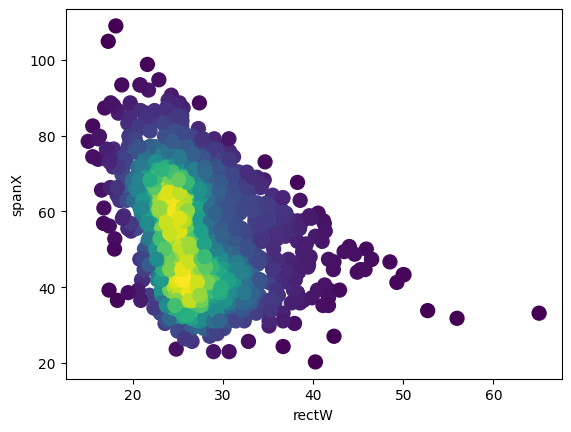

In [50]:
xs = df['rect_width_nm']
ys = df['span_y_nm']
density_plot(xs, ys, xlbl='rectW', ylbl='spanX')